# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [3]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')
    plt.savefig("custom_error.pdf")
    plt.show()
    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')
    plt.savefig("custom_accuracy.pdf")
    plt.show()
    grad_plot, grad_ax = optimiser.plot_grad_flow()
    
    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [4]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/media/fin/KINGSTON/edinburgh_code/mlp/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/media/fin/KINGSTON/edinburgh_code/mlp/data/emnist-valid.npz' with keys: inputs, targets)


In [5]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
# stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
#     model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.
# The Reason
Vanishing gradient problem
Lecturer suggested Kaiming He checking him out, but I should also have a look at what the CustomActivationLayer does as it is likely that it is non differentiable/non continuous as the gradients fail at the 9th layer (i.e the first CustomActivationLayer) 

In [ ]:
# Setup hyperparameters
from mlp.layers import CustomActivationLayer
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_custom, keys_custom, run_time_custom, fig_1_custom, ax_1_custom, fig_2_custom, ax_2_custom, grad_plot_custom, grad_ax_custom = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

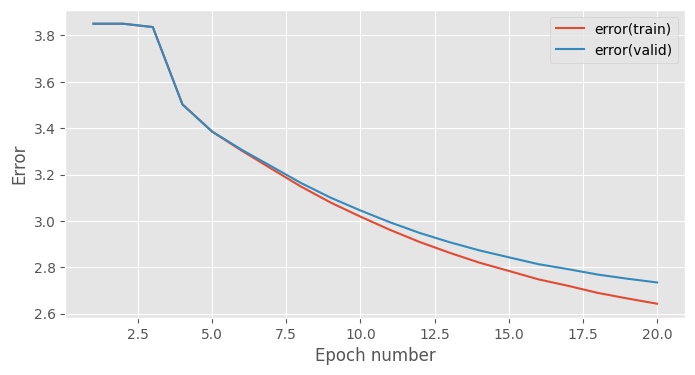

In [122]:
# You can then check the plots like this
fig_1_custom # The training error plot


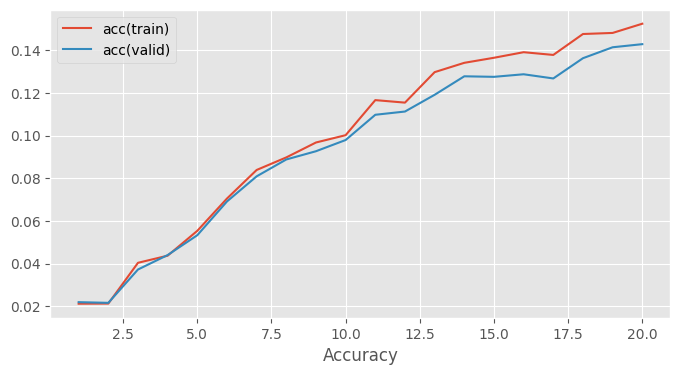

In [123]:
fig_2_custom # The training accuracy plot

In [ ]:
grad_plot_custom.savefig("custom_grad.pdf") # The gradient flow plot

# Task 1.
In this task the first objective is to identify the issue with the current setup solution to the supervised learning problem for EMNIST. This issue is overfitting, in the context of the Bias-Variance tradeoff the model has too high a variance to which results in limitations when attempting to use it on the validation dataset as it becomes more sensitive to the local patterns or small perturbations/assumed noise in the data. This problem is due to the fact that the model currently is has too much representational power, this means that the weights being tuned during the backpropogation algorithms process are being tuned to predict exactly the data too well, they end up capturing the "noise" or unwanted factors of the training set, instead of only learning the generalisable representations or features of the data set to associate with the labels (it picks up the specific local patterns of data rather than the patterns common amongst the entire dataset).

The experiment will be conducted using the following steps:



In [24]:
## Comparison of models with 32, 64 and 128 RELU hidden units per layer on EMNIST.
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim = 784, 47

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# One layer Model with 32 hidden layers
hidden_dim = 32
model_32 = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])
# One layer Model with 64 hidden layers
hidden_dim = 64
model_64 = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])
# One layer Model with 128 hidden layers
hidden_dim = 128
model_128 = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()

learning_rule = AdamLearningRule(learning_rate=learning_rate)

models = [model_32, model_64, model_128]
statistics = []
model_keys = []    

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.5s to complete
    error(train)=1.25e+00, acc(train)=6.52e-01, error(valid)=1.26e+00, acc(valid)=6.47e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.5s to complete
    error(train)=1.12e+00, acc(train)=6.88e-01, error(valid)=1.14e+00, acc(valid)=6.82e-01


...

Epoch 98: 0.6s to complete
    error(train)=5.71e-01, acc(train)=8.19e-01, error(valid)=7.10e-01, acc(valid)=7.84e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.5s to complete
    error(train)=5.72e-01, acc(train)=8.20e-01, error(valid)=7.09e-01, acc(valid)=7.86e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.6s to complete
    error(train)=5.84e-01, acc(train)=8.14e-01, error(valid)=7.19e-01, acc(valid)=7.79e-01


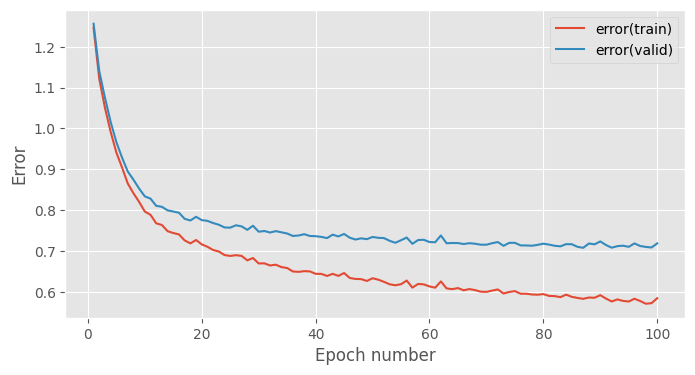

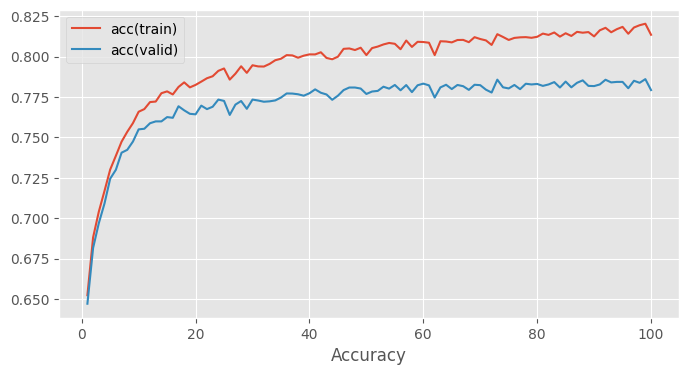

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.9s to complete
    error(train)=1.07e+00, acc(train)=6.96e-01, error(valid)=1.09e+00, acc(valid)=6.94e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.9s to complete
    error(train)=8.88e-01, acc(train)=7.41e-01, error(valid)=9.09e-01, acc(valid)=7.33e-01


...

Epoch 98: 0.9s to complete
    error(train)=3.38e-01, acc(train)=8.82e-01, error(valid)=6.61e-01, acc(valid)=8.11e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.9s to complete
    error(train)=3.31e-01, acc(train)=8.84e-01, error(valid)=6.60e-01, acc(valid)=8.12e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.9s to complete
    error(train)=3.38e-01, acc(train)=8.82e-01, error(valid)=6.68e-01, acc(valid)=8.11e-01


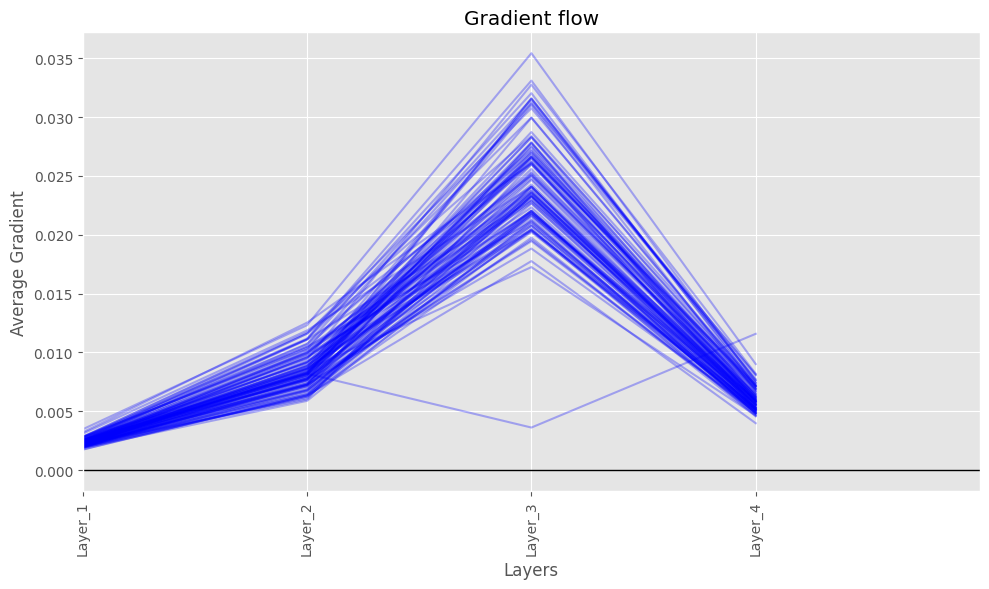

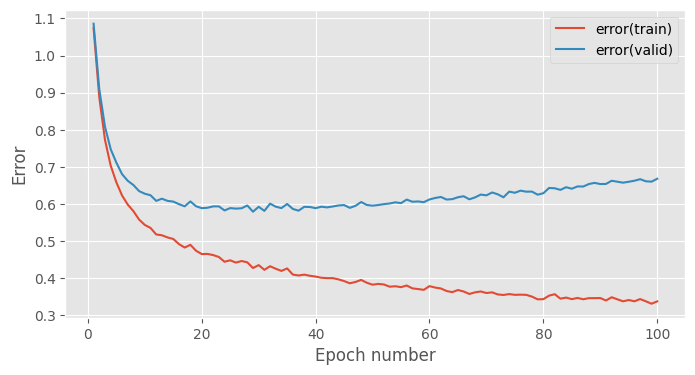

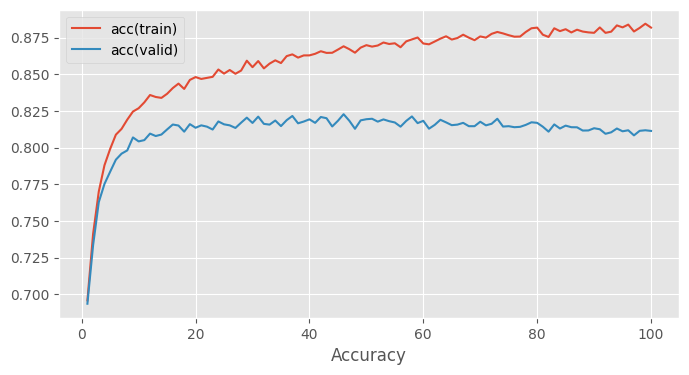

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.4s to complete
    error(train)=9.15e-01, acc(train)=7.36e-01, error(valid)=9.30e-01, acc(valid)=7.34e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.4s to complete
    error(train)=7.04e-01, acc(train)=7.88e-01, error(valid)=7.41e-01, acc(valid)=7.75e-01


...

Epoch 98: 1.4s to complete
    error(train)=1.76e-01, acc(train)=9.31e-01, error(valid)=9.43e-01, acc(valid)=8.06e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.5s to complete
    error(train)=1.57e-01, acc(train)=9.39e-01, error(valid)=9.36e-01, acc(valid)=8.10e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.4s to complete
    error(train)=1.63e-01, acc(train)=9.37e-01, error(valid)=9.53e-01, acc(valid)=8.09e-01


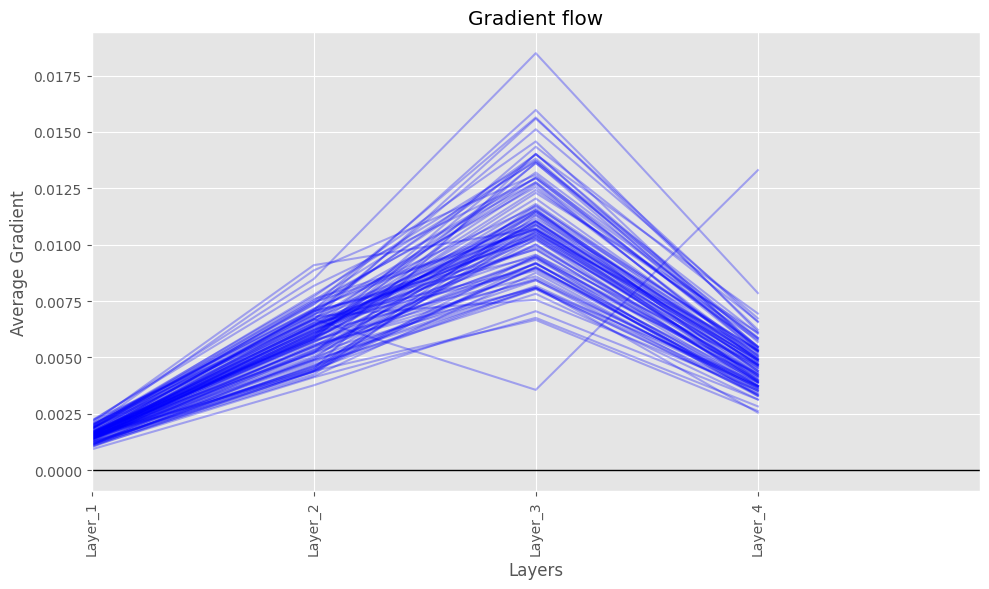

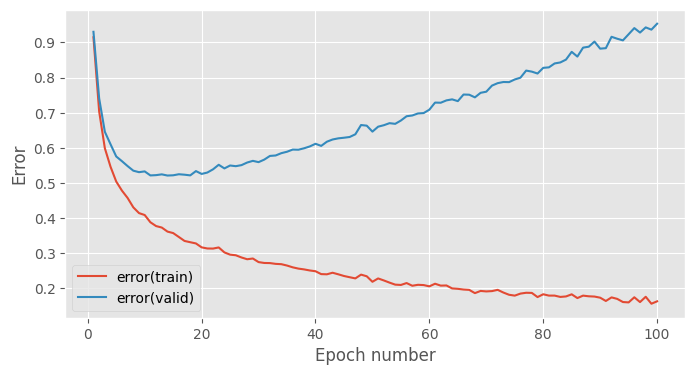

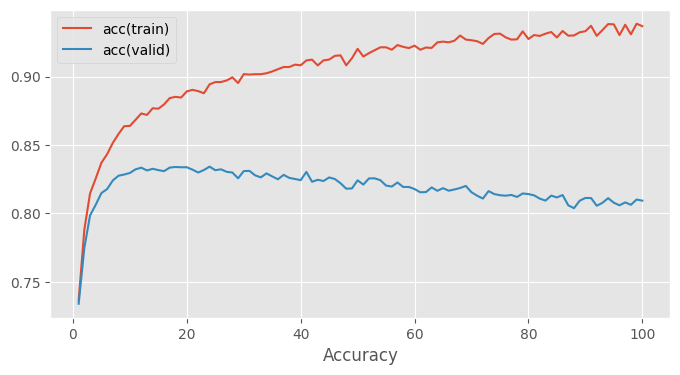

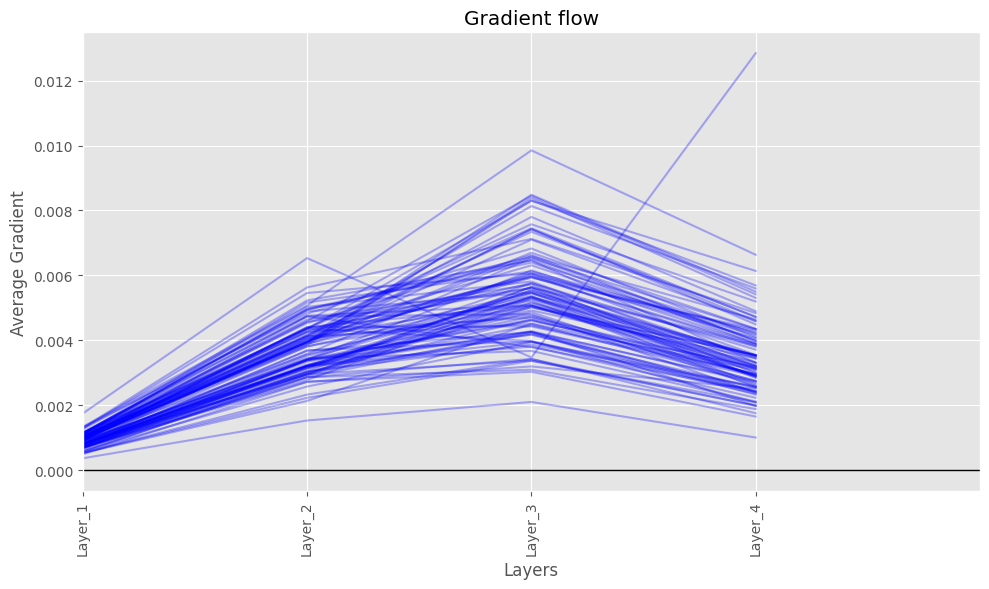

In [25]:
stats_32, keys_32, run_time_32, fig_1_32, ax_1_32, fig_2_32, ax_2_32, grad_plot_32, grad_ax_32 = train_model_and_plot_stats(
    model_32, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_64, keys_64, run_time_64, fig_1_64, ax_1_64, fig_2_64, ax_2_64, grad_plot_64, grad_ax_64 = train_model_and_plot_stats(
    model_64, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_128, keys_128, run_time_128, fig_1_128, ax_1_128, fig_2_128, ax_2_128, grad_plot_128, grad_ax_128 = train_model_and_plot_stats(
    model_128, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)


Valid Accuracy:  0.7793037974683543
Valid Error:  0.7187003060623673
Train Error:  0.5843824809844469
Valid Accuracy:  0.8113924050632906
Valid Error:  0.6680398072038648
Train Error:  0.3377795060624128
Valid Accuracy:  0.8093670886075948
Valid Error:  0.9532476972826635
Train Error:  0.1633490917488612


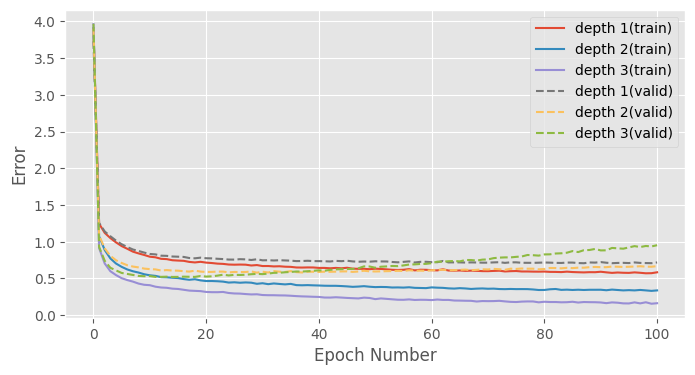

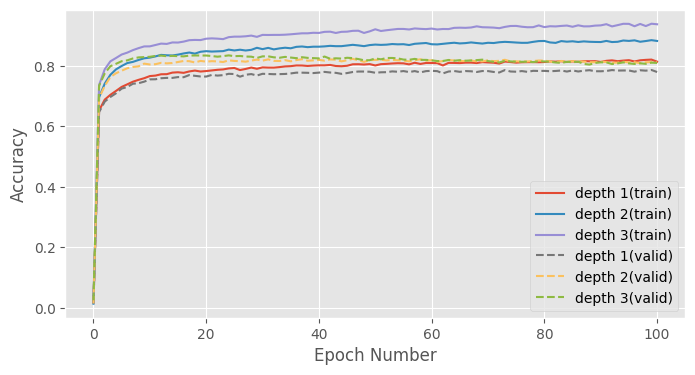

In [58]:
# Statistics and plot for first part of tasks 1 to put in table
key_names = ['error(train)', 'error(valid)', 'acc(train)', 'acc(valid)']
error_figure = plt.figure(figsize=(8,4))
error_plot = error_figure.add_subplot(111)
error_plot.plot(np.arange(stats_32.shape[0]), stats_32[:, keys_32[key_names[0]]], label='depth 1(train)')
error_plot.plot(np.arange(stats_64.shape[0]), stats_64[:, keys_64[key_names[0]]], label='depth 2(train)')
error_plot.plot(np.arange(stats_128.shape[0]), stats_128[:, keys_128[key_names[0]]], label='depth 3(train)')
error_plot.plot(np.arange(stats_32.shape[0]), stats_32[:, keys_32[key_names[1]]], label='depth 1(valid)', linestyle='dashed')
error_plot.plot(np.arange(stats_64.shape[0]), stats_64[:, keys_64[key_names[1]]], label='depth 2(valid)', linestyle='dashed')
error_plot.plot(np.arange(stats_128.shape[0]), stats_128[:, keys_128[key_names[1]]], label='depth 3(valid)', linestyle='dashed')
error_plot.set_ylabel("Error")
error_plot.set_xlabel("Epoch Number")
error_plot.legend()
# plt.show()
plt.savefig("./dim_error.png")

accuracy_figure = plt.figure(figsize=(8,4))
accuracy_plot = accuracy_figure.add_subplot(111)
accuracy_plot.plot(np.arange(stats_32.shape[0]), stats_32[:, keys_32[key_names[2]]], label='depth 1(train)')
accuracy_plot.plot(np.arange(stats_64.shape[0]), stats_64[:, keys_64[key_names[2]]], label='depth 2(train)')
accuracy_plot.plot(np.arange(stats_128.shape[0]), stats_128[:, keys_128[key_names[2]]], label='depth 3(train)')
accuracy_plot.plot(np.arange(stats_32.shape[0]), stats_32[:, keys_32[key_names[3]]], label='depth 1(valid)', linestyle='dashed')
accuracy_plot.plot(np.arange(stats_64.shape[0]), stats_64[:, keys_64[key_names[3]]], label='depth 2(valid)', linestyle='dashed')
accuracy_plot.plot(np.arange(stats_128.shape[0]), stats_128[:, keys_128[key_names[3]]], label='depth 3(valid)', linestyle='dashed')
accuracy_plot.set_ylabel("Accuracy")
accuracy_plot.set_xlabel("Epoch Number")
accuracy_plot.legend()
# plt.show()
plt.savefig("./dim_accuracy.png")

accuracy_function = lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()

# cumulative_valid_accuracy = 0
# for input_batch, output_batch in valid_data:
#     activations = model_32.fprop(input_batch, evaluation=True)[-1]
#     cumulative_valid_accuracy += accuracy_function(activations, output_batch)
# valid_accuracy = cumulative_valid_accuracy / valid_data.num_batches
# print("Valid Accuracy: ", stats_32[:, keys_32[key_names[3]]][-1])
# cumulative_valid_accuracy = 0
# for input_batch, output_batch in train_data:
#     activations = model_32.fprop(input_batch, evaluation=True)[-1]
#     cumulative_valid_accuracy += error(activations, output_batch)

# valid_accuracy = cumulative_valid_accuracy / valid_data.num_batches
# print("Train Error: ", valid_accuracy)
# cumulative_valid_accuracy = 0
# for input_batch, output_batch in valid_data:
#     activations = model_32.fprop(input_batch, evaluation=True)[-1]
#     cumulative_valid_accuracy += error(activations, output_batch)
# valid_accuracy = cumulative_valid_accuracy / valid_data.num_batches
# print("Validation Error: ", valid_accuracy)


# Could do it the long way or just the easy way....
print("Valid Accuracy: ", stats_32[:, keys_32[key_names[3]]][-1])
print("Valid Error: ", stats_32[:, keys_32[key_names[1]]][-1])
print("Train Error: ", stats_32[:, keys_32[key_names[0]]][-1])

print("Valid Accuracy: ", stats_64[:, keys_64[key_names[3]]][-1])
print("Valid Error: ", stats_64[:, keys_64[key_names[1]]][-1])
print("Train Error: ", stats_64[:, keys_64[key_names[0]]][-1])

print("Valid Accuracy: ", stats_128[:, keys_128[key_names[3]]][-1])
print("Valid Error: ", stats_128[:, keys_128[key_names[1]]][-1])
print("Train Error: ", stats_128[:, keys_128[key_names[0]]][-1])



  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=8.95e-01, acc(train)=7.41e-01, error(valid)=9.18e-01, acc(valid)=7.33e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.8s to complete
    error(train)=7.05e-01, acc(train)=7.90e-01, error(valid)=7.41e-01, acc(valid)=7.79e-01


...

Epoch 98: 1.8s to complete
    error(train)=1.81e-01, acc(train)=9.28e-01, error(valid)=9.65e-01, acc(valid)=8.04e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.6s to complete
    error(train)=1.61e-01, acc(train)=9.39e-01, error(valid)=9.50e-01, acc(valid)=8.05e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.6s to complete
    error(train)=1.67e-01, acc(train)=9.34e-01, error(valid)=9.67e-01, acc(valid)=8.07e-01


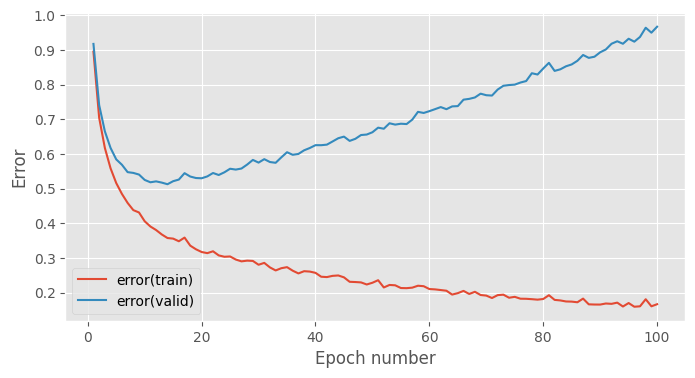

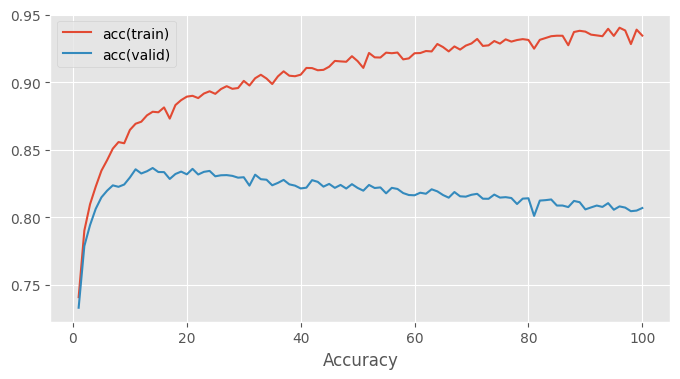

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.0s to complete
    error(train)=7.39e-01, acc(train)=7.74e-01, error(valid)=7.60e-01, acc(valid)=7.66e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.9s to complete
    error(train)=5.66e-01, acc(train)=8.19e-01, error(valid)=6.04e-01, acc(valid)=8.09e-01


...

Epoch 98: 2.2s to complete
    error(train)=1.15e-01, acc(train)=9.54e-01, error(valid)=1.52e+00, acc(valid)=8.18e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.1s to complete
    error(train)=9.68e-02, acc(train)=9.61e-01, error(valid)=1.53e+00, acc(valid)=8.17e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.1s to complete
    error(train)=9.87e-02, acc(train)=9.60e-01, error(valid)=1.54e+00, acc(valid)=8.17e-01


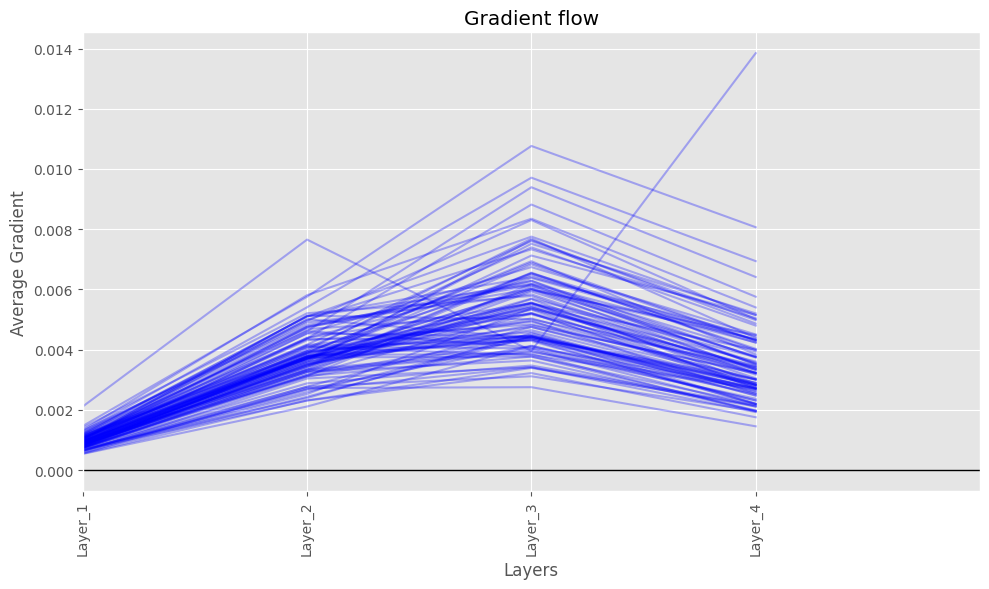

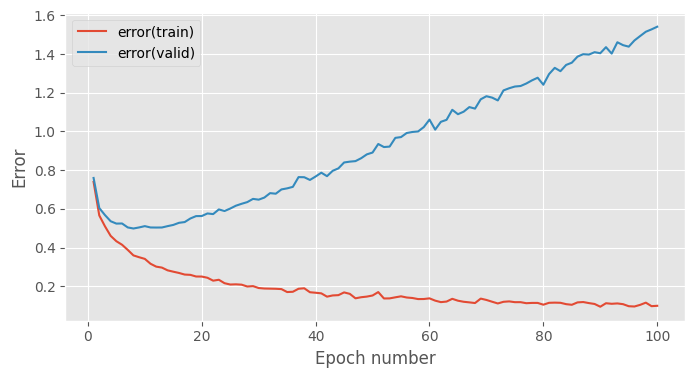

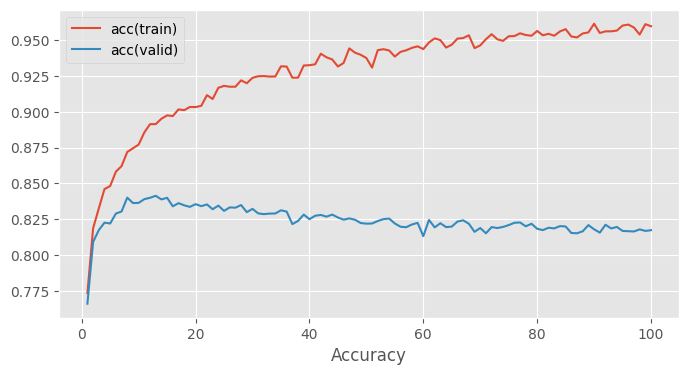

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=6.95e-01, acc(train)=7.82e-01, error(valid)=7.15e-01, acc(valid)=7.73e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 3.7s to complete
    error(train)=5.56e-01, acc(train)=8.17e-01, error(valid)=6.04e-01, acc(valid)=8.01e-01


...

Epoch 98: 1.9s to complete
    error(train)=1.09e-01, acc(train)=9.59e-01, error(valid)=1.63e+00, acc(valid)=8.26e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.9s to complete
    error(train)=1.12e-01, acc(train)=9.56e-01, error(valid)=1.60e+00, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.8s to complete
    error(train)=1.26e-01, acc(train)=9.54e-01, error(valid)=1.70e+00, acc(valid)=8.20e-01


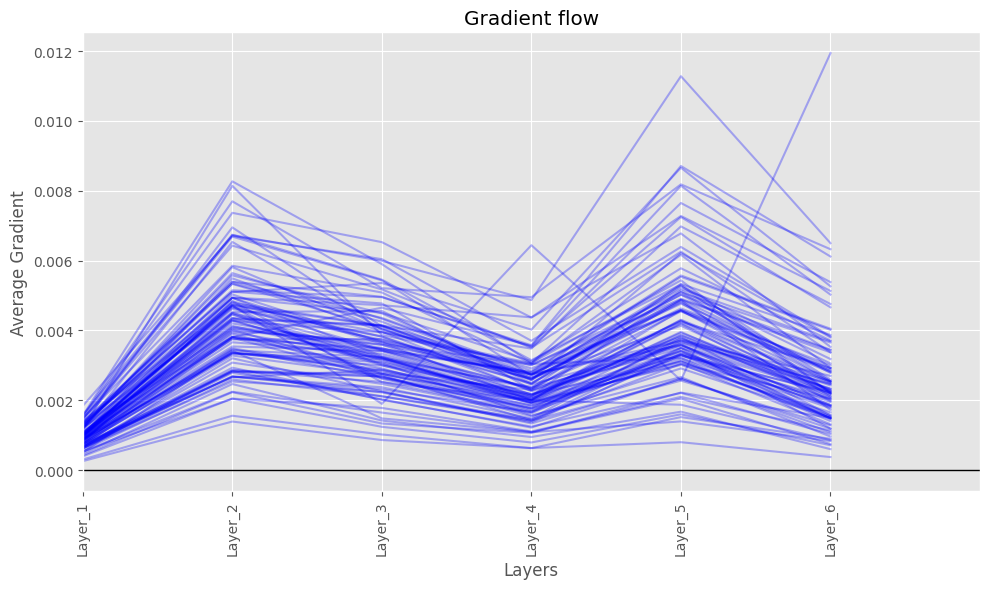

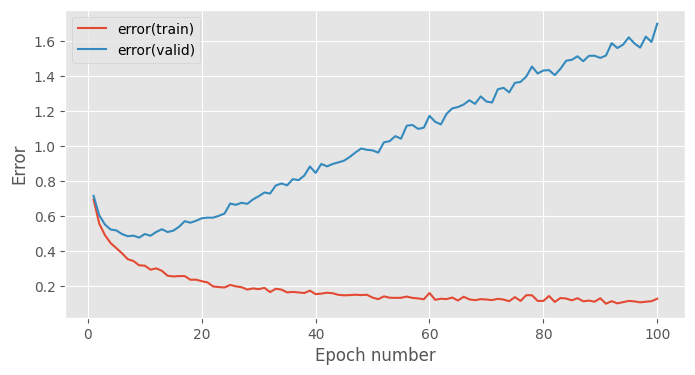

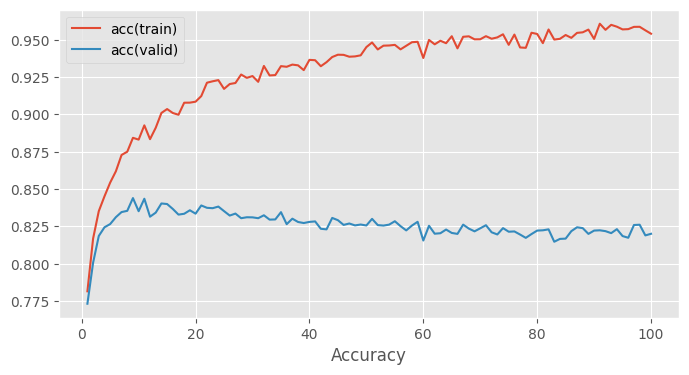

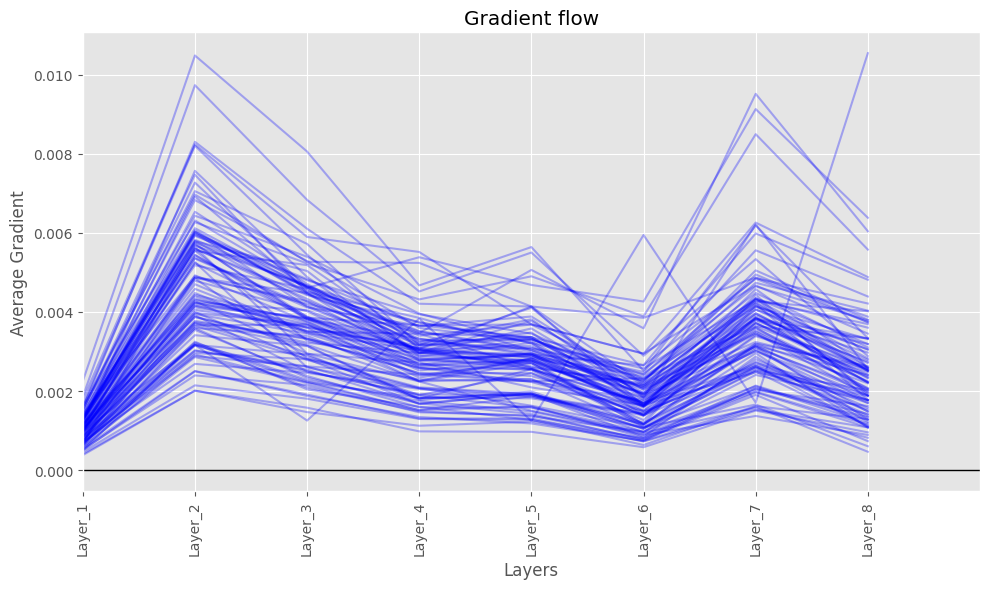

In [11]:
# Task 1
input_dim, output_dim, hidden_dim = 784, 47, 128

model_1_layers = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])
# One layer Model with 64 hidden layers
model_2_layers = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])
# One layer Model with 128 hidden layers
model_3_layers = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

stats_1_layers, keys_1_layers, run_time_1_layers, fig_1_1_layers, ax_1_1_layers, fig_2_1_layers, ax_2_1_layers, grad_plot_1_layers, grad_ax_1_layers = train_model_and_plot_stats(model_1_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_2_layers, keys_2_layers, run_time_2_layers, fig_1_2_layers, ax_1_2_layers, fig_2_2_layers, ax_2_2_layers, grad_plot_2_layers, grad_ax_2_layers = train_model_and_plot_stats(model_2_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_3_layers, keys_3_layers, run_time_3_layers, fig_1_3_layers, ax_1_3_layers, fig_2_3_layers, ax_2_3_layers, grad_plot_3_layers, grad_ax_3_layers = train_model_and_plot_stats(model_3_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)



Valid Accuracy:  0.8067721518987344
Train Error:  0.1669101203692553
Valid Error:  0.9674614659602194
Valid Accuracy:  0.8174050632911387
Train Error:  0.09867429023488078
Valid Error:  1.5418109917870821
Valid Accuracy:  0.8200632911392405
Train Error:  0.12623359617151253
Valid Error:  1.7014386922673237


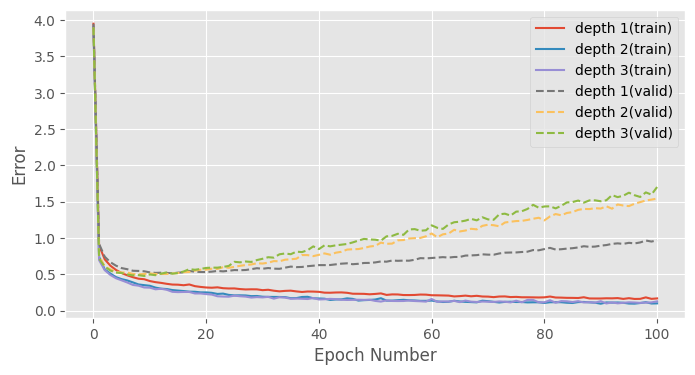

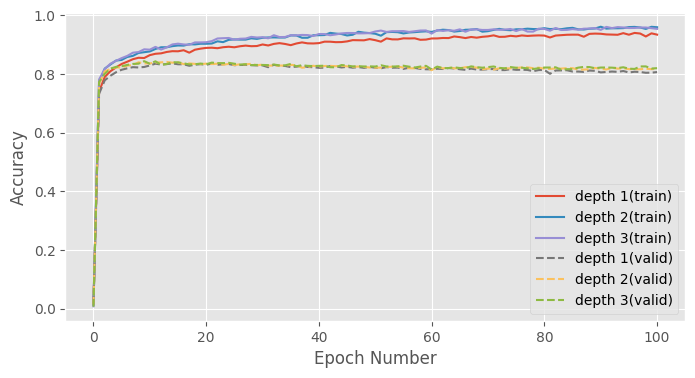

In [77]:
# Statistics and plot for first part of tasks 1 to put in table
# key_names = ['error(train)', 'error(valid)']
error_figure = plt.figure(figsize=(8,4))
error_plot = error_figure.add_subplot(111)
error_plot.plot(np.arange(stats_1_layers.shape[0]), stats_1_layers[:, keys_1_layers[key_names[0]]], label='depth 1(train)')
error_plot.plot(np.arange(stats_2_layers.shape[0]), stats_2_layers[:, keys_2_layers[key_names[0]]], label='depth 2(train)')
error_plot.plot(np.arange(stats_3_layers.shape[0]), stats_3_layers[:, keys_3_layers[key_names[0]]], label='depth 3(train)')
error_plot.plot(np.arange(stats_1_layers.shape[0]), stats_1_layers[:, keys_1_layers[key_names[1]]], label='depth 1(valid)', linestyle='dashed')
error_plot.plot(np.arange(stats_2_layers.shape[0]), stats_2_layers[:, keys_2_layers[key_names[1]]], label='depth 2(valid)', linestyle='dashed')
error_plot.plot(np.arange(stats_3_layers.shape[0]), stats_3_layers[:, keys_3_layers[key_names[1]]], label='depth 3(valid)', linestyle='dashed')
error_plot.set_ylabel("Error")
error_plot.set_xlabel("Epoch Number")
error_plot.legend()
# plt.show()
plt.savefig("./layers_error.png")
valid_figure = plt.figure(figsize=(8,4))
valid_plot = valid_figure.add_subplot(111)
valid_plot.plot(np.arange(stats_1_layers.shape[0]), stats_1_layers[:, keys_1_layers[key_names[2]]], label='depth 1(train)')
valid_plot.plot(np.arange(stats_2_layers.shape[0]), stats_2_layers[:, keys_2_layers[key_names[2]]], label='depth 2(train)')
valid_plot.plot(np.arange(stats_3_layers.shape[0]), stats_3_layers[:, keys_3_layers[key_names[2]]], label='depth 3(train)')
valid_plot.plot(np.arange(stats_1_layers.shape[0]), stats_1_layers[:, keys_1_layers[key_names[3]]], label='depth 1(valid)', linestyle='dashed')
valid_plot.plot(np.arange(stats_2_layers.shape[0]), stats_2_layers[:, keys_2_layers[key_names[3]]], label='depth 2(valid)', linestyle='dashed')
valid_plot.plot(np.arange(stats_3_layers.shape[0]), stats_3_layers[:, keys_3_layers[key_names[3]]], label='depth 3(valid)', linestyle='dashed')
valid_plot.set_ylabel("Accuracy")
valid_plot.set_xlabel("Epoch Number")
valid_plot.legend()
# plt.show()
plt.savefig("./layers_accuracy.png")
# 
print("Valid Accuracy: ", stats_1_layers[:, keys_1_layers[key_names[3]]][-1])
print("Train Error: ", stats_1_layers[:, keys_1_layers[key_names[0]]][-1])
print("Valid Error: ", stats_1_layers[:, keys_1_layers[key_names[1]]][-1])

print("Valid Accuracy: ", stats_2_layers[:, keys_2_layers[key_names[3]]][-1])
print("Train Error: ", stats_2_layers[:, keys_2_layers[key_names[0]]][-1])
print("Valid Error: ", stats_2_layers[:, keys_2_layers[key_names[1]]][-1])

print("Valid Accuracy: ", stats_3_layers[:, keys_3_layers[key_names[3]]][-1])
print("Train Error: ", stats_3_layers[:, keys_3_layers[key_names[0]]][-1])
print("Valid Error: ", stats_3_layers[:, keys_3_layers[key_names[1]]][-1])


In [14]:
# input_dim, output_dim, hidden_dim = 784, 47, 128

# model_1_layers = MultipleLayerModel([
#     AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
# ])
# # One layer Model with 64 hidden layers
# model_2_layers = MultipleLayerModel([
#     AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
# ])
# # One layer Model with 128 hidden layers
# model_3_layers = MultipleLayerModel([
#     AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
#     ReluLayer(),
#     AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
# ])

# stats_1_layers, keys_1_layers, run_time_1_layers, fig_1_1_layers, ax_1_1_layers, fig_2_1_layers, ax_2_1_layers, grad_plot_1_layers, grad_ax_1_layers = train_model_and_plot_stats(model_1_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

# stats_2_layers, keys_2_layers, run_time_2_layers, fig_1_2_layers, ax_1_2_layers, fig_2_2_layers, ax_2_2_layers, grad_plot_2_layers, grad_ax_2_layers = train_model_and_plot_stats(model_2_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

# stats_3_layers, keys_3_layers, run_time_3_layers, fig_1_3_layers, ax_1_3_layers, fig_2_3_layers, ax_2_3_layers, grad_plot_3_layers, grad_ax_3_layers = train_model_and_plot_stats(model_3_layers, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)


In [ ]:
input_dim, output_dim, hidden_dim = 784, 47, 128

from mlp.layers import DropoutLayer

dropout_model = lambda p: MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    DropoutLayer(rng=rng, incl_prob=p),  
    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    DropoutLayer(rng=rng, incl_prob=p), 
    
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)  
])
dropout_models = [dropout_model(0.6),dropout_model(0.7),dropout_model(0.85),dropout_model(0.97)]

stats_dropout_06, keys_dropout_06, run_dropout_06, fig_1_dropout_06, ax_1_dropout_06, fig_2_dropout_06, ax_2_dropout_06, grad_plot_dropout_06, grad_ax_dropout_06 = train_model_and_plot_stats(dropout_models[0], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_dropout_07, keys_dropout_07, run_dropout_07, fig_1_dropout_07, ax_1_dropout_07, fig_2_dropout_07, ax_2_dropout_07, grad_plot_dropout_07, grad_ax_dropout_07 = train_model_and_plot_stats(dropout_models[1], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_dropout_085, keys_dropout_085, run_dropout_085, fig_1_dropout_085, ax_1_dropout_085, fig_2_dropout_085, ax_2_dropout_085, grad_plot_dropout_085, grad_ax_dropout_085 = train_model_and_plot_stats(dropout_models[2], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_dropout_097, keys_dropout_097, run_dropout_097, fig_1_dropout_097, ax_1_dropout_097, fig_2_dropout_097, ax_2_dropout_097, grad_plot_dropout_097, grad_ax_dropout_097 = train_model_and_plot_stats(dropout_models[3], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)



In [76]:
print(stats_dropout_07[-1, keys_dropout_07["acc(valid)"]])
print(stats_dropout_07[-1, keys_dropout_07["error(train)"]])
print(stats_dropout_07[-1, keys_dropout_07["error(valid)"]])


0.839050632911392
0.34942213921542686
0.4756320080782732


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.2s to complete
    error(train)=1.03e+00, acc(train)=7.02e-01, error(valid)=1.03e+00, acc(valid)=7.01e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.1s to complete
    error(train)=8.98e-01, acc(train)=7.31e-01, error(valid)=9.01e-01, acc(valid)=7.24e-01


...

Epoch 98: 2.2s to complete
    error(train)=5.70e-01, acc(train)=8.17e-01, error(valid)=5.94e-01, acc(valid)=8.10e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.1s to complete
    error(train)=5.62e-01, acc(train)=8.19e-01, error(valid)=5.86e-01, acc(valid)=8.11e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.1s to complete
    error(train)=5.70e-01, acc(train)=8.16e-01, error(valid)=5.88e-01, acc(valid)=8.07e-01


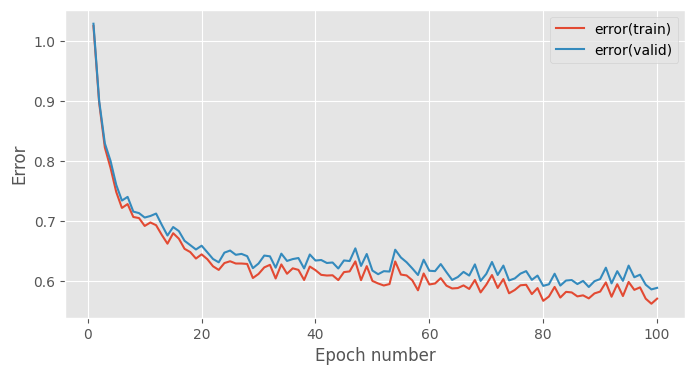

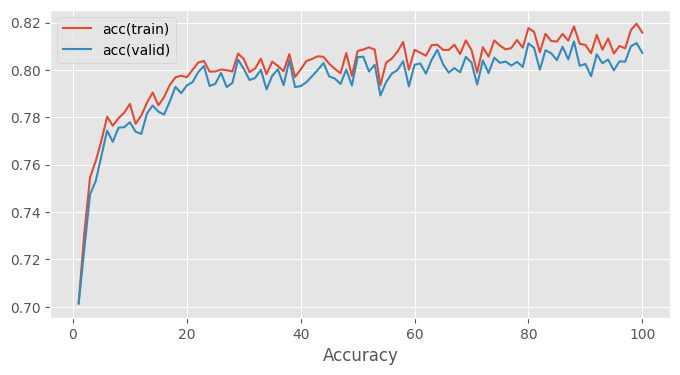

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.0s to complete
    error(train)=1.29e+00, acc(train)=6.36e-01, error(valid)=1.30e+00, acc(valid)=6.33e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.1s to complete
    error(train)=1.15e+00, acc(train)=6.68e-01, error(valid)=1.16e+00, acc(valid)=6.63e-01


...

Epoch 98: 2.8s to complete
    error(train)=7.80e-01, acc(train)=7.57e-01, error(valid)=8.00e-01, acc(valid)=7.53e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.5s to complete
    error(train)=7.63e-01, acc(train)=7.64e-01, error(valid)=7.78e-01, acc(valid)=7.60e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.1s to complete
    error(train)=7.71e-01, acc(train)=7.63e-01, error(valid)=7.92e-01, acc(valid)=7.58e-01


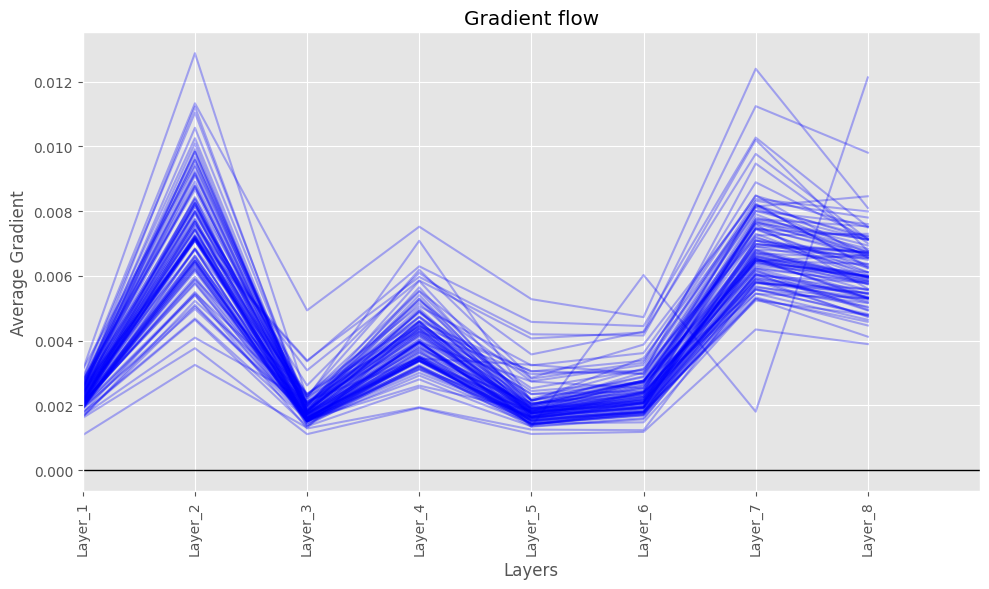

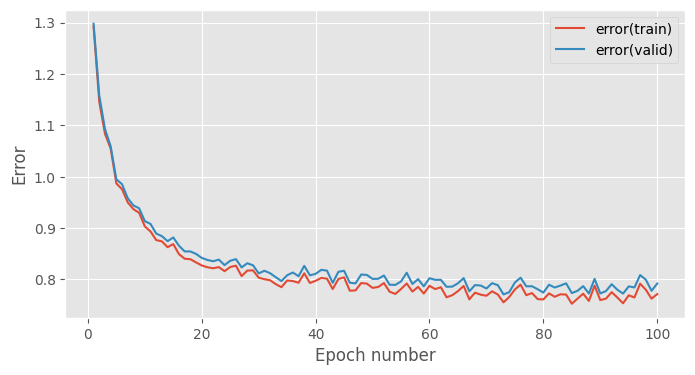

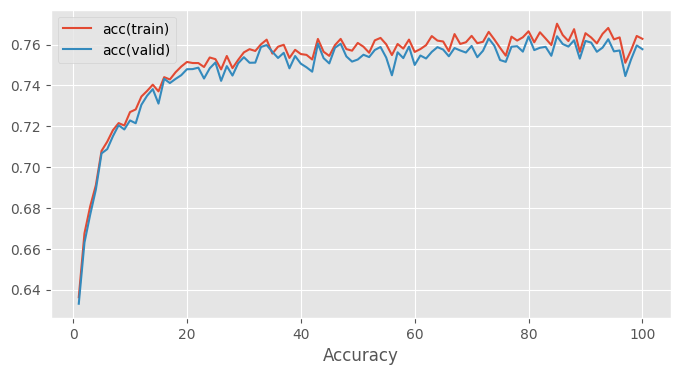

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.1s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.01e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.0s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


...

Epoch 98: 1.9s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.98e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.9s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.04e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.3s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.07e-02


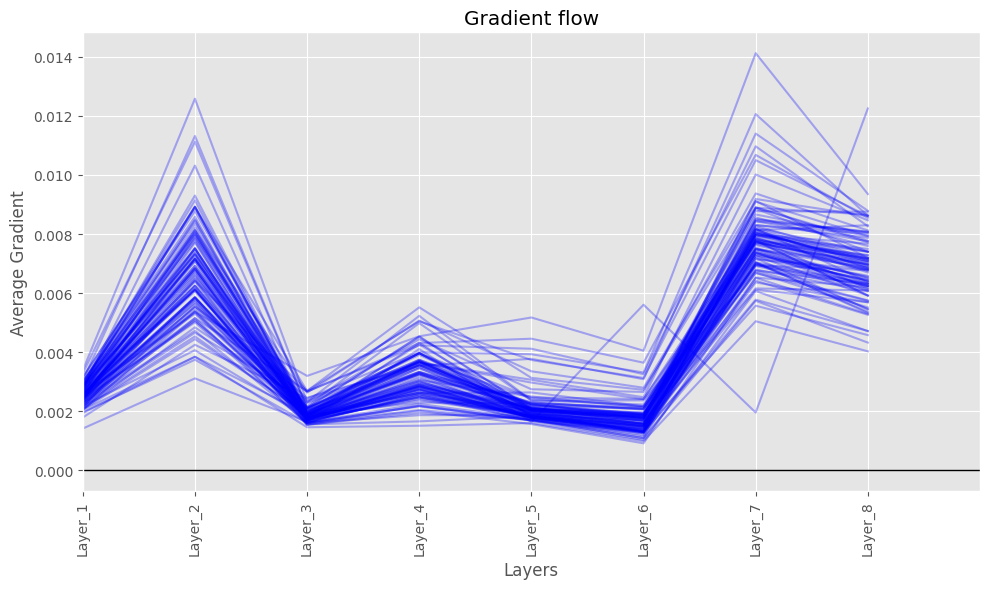

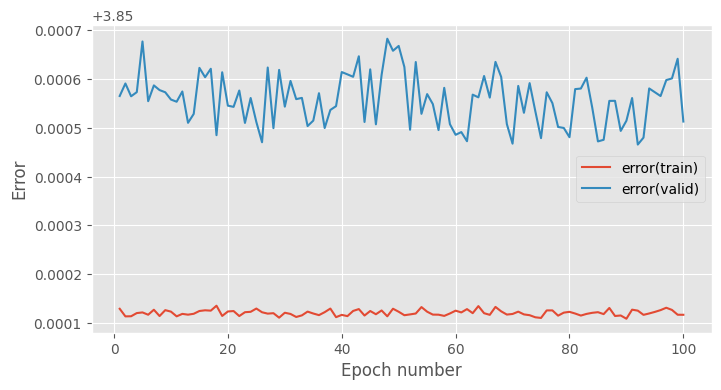

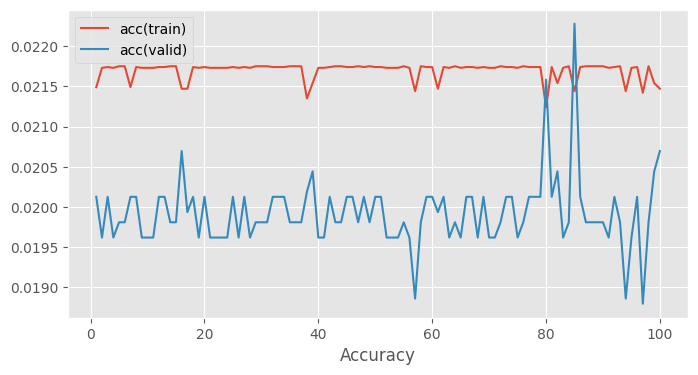

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.5s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


...

Epoch 98: 1.9s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.9s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=2.01e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.9s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


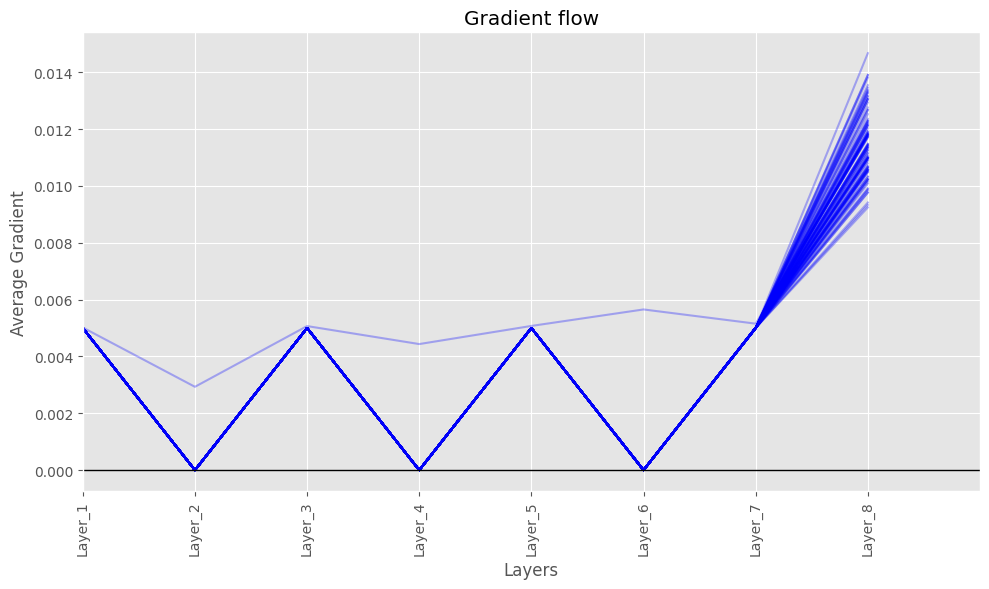

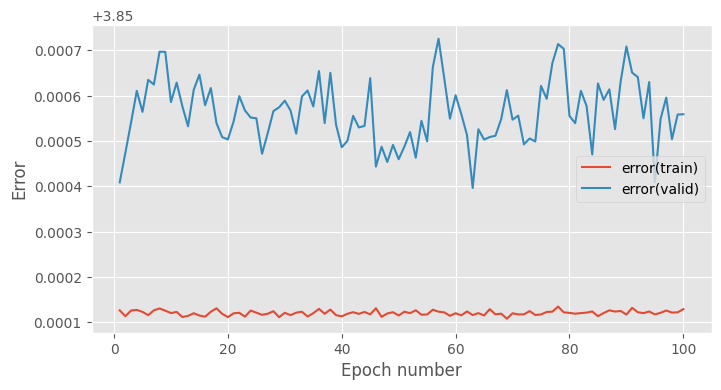

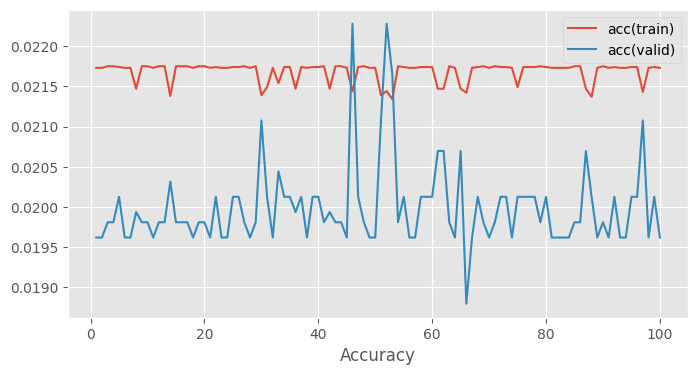

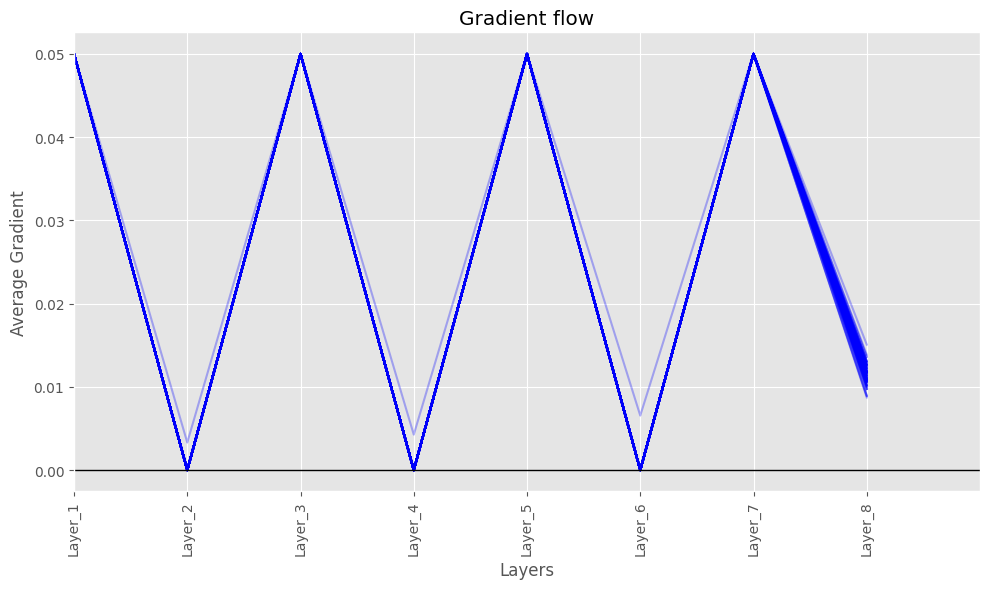

In [7]:
input_dim, output_dim, hidden_dim = 784, 47, 128
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

L1_model = lambda p: MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1Penalty(p))  
])
L1_models = [L1_model(5e-4),L1_model(1e-3),L1_model(5e-3),L1_model(5e-2)]

stats_L1_5e4, keys_L1_5e4, run_L1_5e4, fig_1_L1_5e4, ax_1_L1_5e4, fig_2_L1_5e4, ax_2_L1_5e4, grad_plot_L1_5e4, grad_ax_L1_5e4 = train_model_and_plot_stats(L1_models[0], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L1_1e3, keys_L1_1e3, run_L1_1e3, fig_1_L1_1e3, ax_1_L1_1e3, fig_2_L1_1e3, ax_2_L1_1e3, grad_plot_L1_1e3, grad_ax_L1_1e3 = train_model_and_plot_stats(L1_models[1], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L1_5e3, keys_L1_5e3, run_L1_5e3, fig_1_L1_5e3, ax_1_L1_5e3, fig_2_L1_5e3, ax_2_L1_5e3, grad_plot_L1_5e3, grad_ax_L1_5e3 = train_model_and_plot_stats(L1_models[2], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L1_5e2, keys_L1_5e2, run_L1_5e2, fig_1_L1_5e2, ax_1_L1_5e2, fig_2_L1_5e2, ax_2_L1_5e2, grad_plot_L1_5e2, grad_ax_L1_5e2 = train_model_and_plot_stats(L1_models[3], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [74]:
print(stats_L1_1e3[-1, keys_L1_1e3["acc(valid)"]])
print(stats_L1_1e3[-1, keys_L1_1e3["error(train)"]])
print(stats_L1_1e3[-1, keys_L1_1e3["error(valid)"]])


0.7586075949367088
0.7717923806259204
0.7884655230541298


In [ ]:
input_dim, output_dim, hidden_dim = 784, 47, 128

L2_model = lambda p: MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(p)),
    ReluLayer(),    
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L2Penalty(p))  
])
L2_models = [L2_model(5e-4),L2_model(1e-3),L2_model(5e-3),L2_model(5e-2)]

stats_L2_5e4, keys_L2_5e4, run_L2_5e4, fig_1_L2_5e4, ax_1_L2_5e4, fig_2_L2_5e4, ax_2_L2_5e4, grad_plot_L2_5e4, grad_ax_L2_5e4 = train_model_and_plot_stats(L2_models[0], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L2_1e3, keys_L2_1e3, run_L2_1e3, fig_1_L2_1e3, ax_1_L2_1e3, fig_2_L2_1e3, ax_2_L2_1e3, grad_plot_L2_1e3, grad_ax_L2_1e3 = train_model_and_plot_stats(L2_models[1], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L2_5e3, keys_L2_5e3, run_L2_5e3, fig_1_L2_5e3, ax_1_L2_5e3, fig_2_L2_5e3, ax_2_L2_5e3, grad_plot_L2_5e3, grad_ax_L2_5e3 = train_model_and_plot_stats(L2_models[2], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

stats_L2_5e2, keys_L2_5e2, run_L2_5e2, fig_1_L2_5e2, ax_1_L2_5e2, fig_2_L2_5e2, ax_2_L2_5e2, grad_plot_L2_5e2, grad_ax_L2_5e2 = train_model_and_plot_stats(L2_models[3], error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.8s to complete
    error(train)=7.11e-01, acc(train)=7.75e-01, error(valid)=7.34e-01, acc(valid)=7.71e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.4s to complete
    error(train)=5.57e-01, acc(train)=8.18e-01, error(valid)=5.92e-01, acc(valid)=8.08e-01


...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 92: 4.4s to complete
    error(train)=2.86e-01, acc(train)=8.93e-01, error(valid)=4.14e-01, acc(valid)=8.57e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 93: 8.2s to complete
    error(train)=2.73e-01, acc(train)=8.99e-01, error(valid)=4.02e-01, acc(valid)=8.62e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

In [132]:
print(stats_L2_1e3[-1, keys_L2_1e3["acc(valid)"]])
print(stats_L2_1e3[-1, keys_L2_1e3["error(train)"]])
print(stats_L2_1e3[-1, keys_L2_1e3["error(valid)"]])
num_p=0
for param in L2_model(5e-3).params:
    print(param.shape)
    if len(param.shape) > 1 and param.shape[1]:
        num_p += param.shape[0]*param.shape[1] 
    else:
        num_p += param.shape[0]
num_p

0.8540506329113922
0.36140688027424206
0.42577917106074276
(128, 784)
(128,)
(128, 128)
(128,)
(128, 128)
(128,)
(47, 128)
(47,)


139567

KeysView(NpzFile '/media/fin/KINGSTON/edinburgh_code/mlp/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/media/fin/KINGSTON/edinburgh_code/mlp/data/emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=1.36e+00, acc(train)=7.94e-01, error(valid)=1.38e+00, acc(valid)=7.84e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 98: 2.4s to complete
    error(train)=8.50e-01, acc(train)=9.64e-01, error(valid)=1.25e+00, acc(valid)=8.26e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.4s to complete
    error(train)=8.49e-01, acc(train)=9.65e-01, error(valid)=1.25e+00, acc(valid)=8.29e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.2s to complete
    error(train)=8.46e-01, acc(train)=9.67e-01, error(valid)=1.25e+00, acc(valid)=8.25e-01


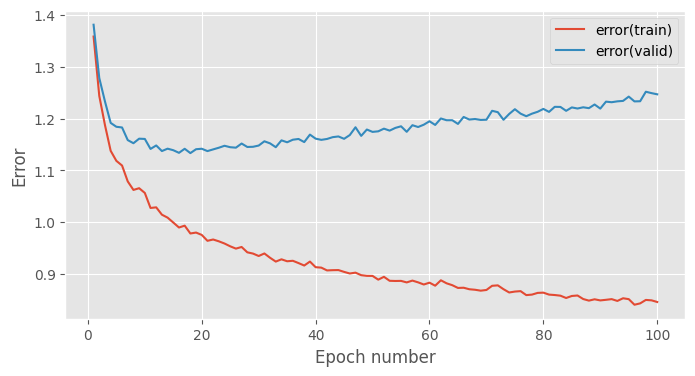

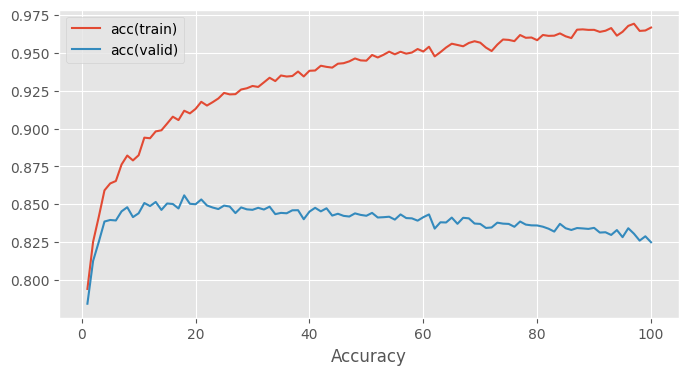

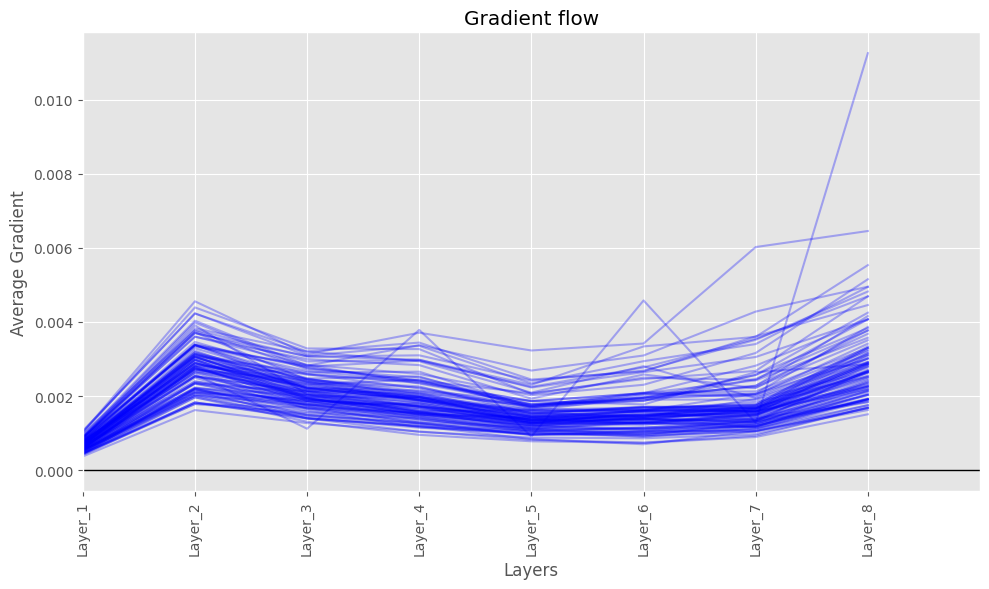

In [95]:
smooth_train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)
smooth_valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=True)

model_for_label_smoothing = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])
stats_smooth_label, keys_smooth_label, run_smooth_label, fig_1_smooth_label, ax_1_smooth_label, fig_2_smooth_label, ax_2_smooth_label, grad_plot_smooth_label, grad_ax_smooth_label = train_model_and_plot_stats(model_for_label_smoothing, error, learning_rule, smooth_train_data, smooth_valid_data, num_epochs, stats_interval, notebook=True)


In [78]:
print(stats_smooth_label[-1, keys_smooth_label["acc(valid)"]])
print(stats_smooth_label[-1, keys_smooth_label["error(train)"]])
print(stats_smooth_label[-1, keys_smooth_label["error(valid)"]])


0.831898734177215
0.8501004667800033
1.2369634718372577


# 2 Training Runs of Experiments
L1 + L2 experiment
We will now examine the test performance of this model.

In [15]:
input_dim, output_dim, hidden_dim = 784, 47, 128

L12_model = lambda l: MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty(l)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty(l)),
    ReluLayer(),    
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty(l)),
    ReluLayer(),    
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1L2MixPenalty(l))  
])
L12_models = [L2_model(5e-4),L2_model(1e-3),L2_model(1e-4),L2_model(1e-5)]
L12_results = []
for model in L12_models:
    L12_results.append(train_model_and_plot_stats(model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True))
    print(L12_results)


In [ ]:
key_names = ['error(train)', 'error(valid)', 'acc(train)', 'acc(valid)']

for result in L12_results:
    print("Valid Accuracy: ", result.stats[:, result.keys[key_names[3]]][-1])
    print("Train Error: ", result.stats[:, result.keys[key_names[0]]][-1])
    print("Valid Error: ", result.stats[:, result.keys[key_names[1]]][-1])


In [79]:
test_data = EMNISTDataProvider('test', batch_size=batch_size, rng=rng)
test_data


KeysView(NpzFile '/media/fin/KINGSTON/edinburgh_code/mlp/data/emnist-test.npz' with keys: inputs, targets)


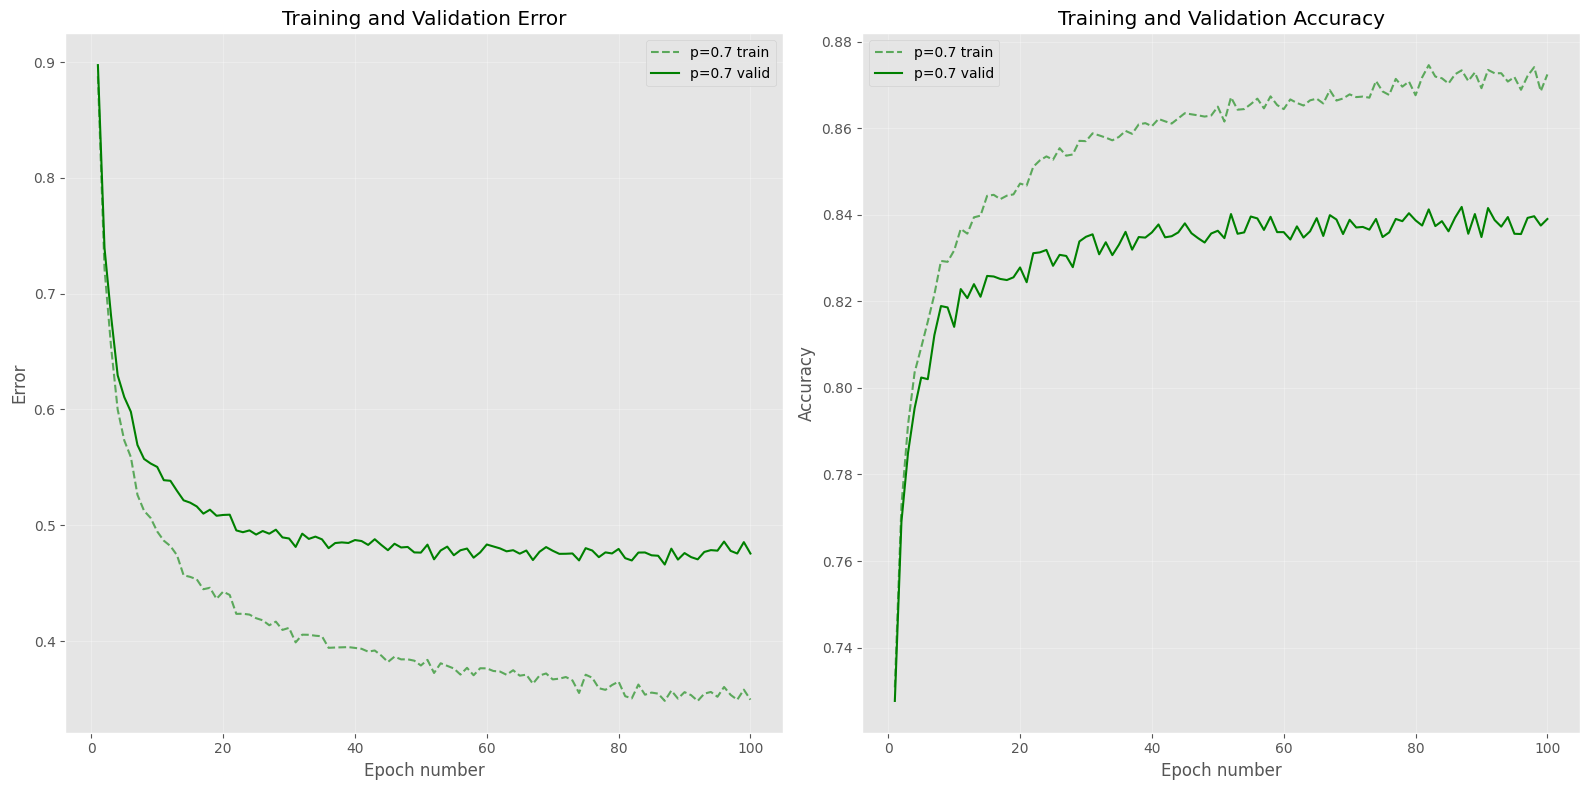

In [62]:
# Combine all dropout model results into one comparison plot
fig_combined = plt.figure(figsize=(16, 8))

# Error comparison
ax_error = fig_combined.add_subplot(1, 2, 1)
for stats, keys, label, color in [
    # (stats_dropout_06, keys_dropout_06, 'p=0.6', 'blue'),
    (stats_dropout_07, keys_dropout_07, 'p=0.7', 'green'),
    # (stats_dropout_085, keys_dropout_085, 'p=0.85', 'orange'),
    # (stats_dropout_097, keys_dropout_097, 'p=0.97', 'red')
]:
    epochs = np.arange(1, stats.shape[0]) * stats_interval
    ax_error.plot(epochs, stats[1:, keys['error(train)']], 
                  linestyle='--', color=color, alpha=0.6, label=f'{label} train')
    ax_error.plot(epochs, stats[1:, keys['error(valid)']], 
                  linestyle='-', color=color, label=f'{label} valid')

ax_error.legend(loc='best')
ax_error.set_xlabel('Epoch number')
ax_error.set_ylabel('Error')
ax_error.set_title('Training and Validation Error')
ax_error.grid(True, alpha=0.3)

# Accuracy comparison
ax_acc = fig_combined.add_subplot(1, 2, 2)
for stats, keys, label, color in [
    # (stats_dropout_06, keys_dropout_06, 'p=0.6', 'blue'),
    (stats_dropout_07, keys_dropout_07, 'p=0.7', 'green'),
    # (stats_dropout_085, keys_dropout_085, 'p=0.85', 'orange'),
    # (stats_dropout_097, keys_dropout_097, 'p=0.97', 'red')
]:
    epochs = np.arange(1, stats.shape[0]) * stats_interval
    ax_acc.plot(epochs, stats[1:, keys['acc(train)']], 
                linestyle='--', color=color, alpha=0.6, label=f'{label} train')
    ax_acc.plot(epochs, stats[1:, keys['acc(valid)']], 
                linestyle='-', color=color, label=f'{label} valid')

ax_acc.legend(loc='best')
ax_acc.set_xlabel('Epoch number')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_title('Training and Validation Accuracy')
ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Trainingvalidation.png")

# 